<a href="https://colab.research.google.com/github/asndjkasdnjkasdjnkasdj/-Lab01_EDA_Azocar_Benjamin/blob/main/Benjamin_Azocar_Evaluacion1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación Final Unidad 1

## 1. El Problema.

Enlace Repositorio GitHub: https://github.com/asndjkasdnjkasdjnkasdj/-Lab01_EDA_Azocar_Benjamin/blob/main/Benjamin_Azocar_Evaluacion1.ipynb

## Business Understading

### Determinacion de los Objetivos del negocio:

Contexto del proyecto:
Este proyecto simula el contexto de una institucion educativa interesada en comprender como o que factores influyen en el rendimiento academico de sus estudiantes con el fin de diseñar estrategias de apoyo o de alerta temprana.

Objetivos del negocio: Comprender patrones de conducta en los estudiantes para saber como su estilo de vida influye en su rendimiento academico.

Criterios de exito:
Contar de un modelo interpretable que permita identificar principales factores asociados al rendimiento academico de los estudiantes.
Disponer de una herramienta capaz de predecir estudiantes en riesgo de bajo rendimiento.

## Evaluacion de la situacion:

Disponibilidad de recursos: Base de datos institucional que contiene registros de asistencia, calificaciones, habitos de estudio y datos demograficos.

Requisitos del proyecto: Datos actualizados de los estudiantes, consentimiento informado de datos sensibles.

Riesgos: Ante los resultados no proceder de manera inmediata con un estudiante sino trabajar con el equipo docente a la par.

## Objetivos de la Mineria de Datos:

Constuir un modelo predictivo que pueda predecir correctamente el puntaje final de examen.

Realizar un analisis exploratorio de datos (eda) y un analisis de importancia de variables (feature importance) para identificar que factores tienen mayor influencia sobre el rendimiento academico.





## 2. Los datos.

Enlace del dataset: https://www.kaggle.com/datasets/harshadapatil31/student-performance-and-study-habits-dataset.

License CC0: Public Domain.

Autor: Harshada Patil

### Justificación de atributos:

1. gender (Categorica): Nos permite entender si existen diferencias de rendimiento asociadas al genero.

2. study_time_hours (Numérica continua): Variable conductual central: mas horas de estudio debieran asociarse a mejor rendimiento.

3. attendance_percent (Numérica continua): Indicador temprano de compromiso academico.

4.  sleep_hours (Numérica continua): Factor de estilo de vida que afecta la concentracion y el rendimiento cognitivo.

5. parental_education (Categorica): Contexto socioeducativo del hogar.

6. internet_access (Categorica): Refleja acceso a recursos educativos en internet (tareas online, material de apoyo, etc.).

7. extracurricular_activities (Categorica): Permite evaluar si compite con el tiempo de estudio o se asocia a mejor rendimiento.

8. part_time_job (Categorica): Reduce el tiempo disponible para estudiar.

9. previous_grade (Numerica continua): El rendimiento historico suele predecir el rendimiento futuro.

10. final_exam_score (Numerica continua): Version numerica del resultado, se usa para EDA aunque no como variable objetivo.

11. final_grade (Categorica: 5 Clases) - Variable objetivo: Se elige por sobre final_exam_score debido a la exigencia de una variable objetivo categorica.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")
print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [5]:
from google.colab import files
archivos_subidos = files.upload()
nombre_csv = next(iter(archivos_subidos))
print("Archivo seleccionado:", nombre_csv)

Saving student_performance_dataset.csv to student_performance_dataset.csv
Archivo seleccionado: student_performance_dataset.csv


In [6]:
df = pd.read_csv(nombre_csv)
print("Filas:", df.shape[0], "| Columnas:", df.shape[1])
df.head()

Filas: 1000 | Columnas: 12


,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D


## 3. EDA y preparación.




### 3.1 Exploración inicial.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   object 
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    object 
 6   internet_access             1000 non-null   object 
 7   extracurricular_activities  1000 non-null   object 
 8   part_time_job               1000 non-null   object 
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   object 
dtypes: float64(5), int64(1), object(6)
memory usage: 93.9+ KB


In [8]:
df.describe()

,student_id,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,3.570700,85.092300,6.799500,69.740900,83.543500
std,288.819436,1.478559,9.270685,1.203527,12.613425,10.341333
min,1.000000,0.500000,54.800000,3.200000,31.300000,46.800000
25%,250.750000,2.600000,78.800000,5.900000,61.000000,76.075000
50%,500.500000,3.600000,85.200000,6.800000,69.600000,83.800000
75%,750.250000,4.500000,91.900000,7.600000,78.400000,91.525000
max,1000.000000,8.100000,100.000000,10.000000,100.000000,100.000000


In [9]:
nulos = df.isnull().sum()
nulos = nulos[nulos > 0]
print("Columnas con nulos:")
print(nulos)
print()
print("Porcentaje de nulos en parental_education:",
      round(df['parental_education'].isnull().mean() * 100, 2), "%")

Columnas con nulos:
parental_education    102
dtype: int64

Porcentaje de nulos en parental_education: 10.2 %


### Decisión sobre los nulos:

Se decidió crear una categoría explícita "Desconocido" en vez de eliminar las 102 filas afectadas. Eliminarlas habría significado perder el 10.2% de los datos, un porcentaje demasiado alto para descartar sin justificación sólida — sobre todo porque no hay evidencia de que la ausencia del dato esté relacionada con el rendimiento académico (es decir, no parece un patrón de nulos "informativo" que debiera excluirse, sino más bien un vacío de registro). Mantener estas filas con una categoría propia permite conservar toda la muestra y, de paso, permite comprobar en las reglas de asociación si "Desconocido" se comporta distinto a las demás categorías.

In [10]:
df['parental_education'] = df['parental_education'].fillna('Desconocido')
df['parental_education'].value_counts()

,count
parental_education,
High School,356
Bachelors,308
Masters,184
Desconocido,102
PhD,50


### 3.2 Visualizaciones.

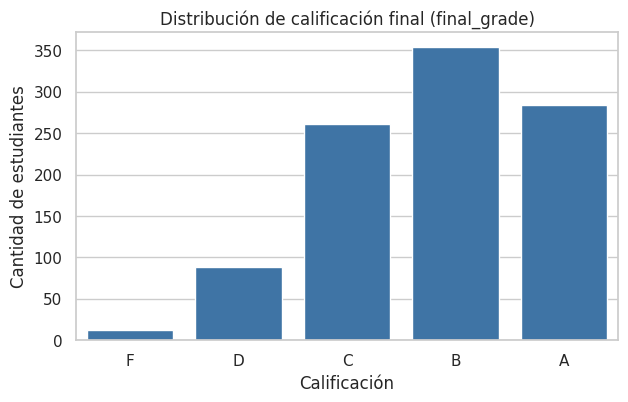

In [11]:
plt.figure(figsize=(7,4))
orden = ['F', 'D', 'C', 'B', 'A']
sns.countplot(data=df, x='final_grade', order=orden, color="#2E75B6")
plt.title("Distribución de calificación final (final_grade)")
plt.xlabel("Calificación")
plt.ylabel("Cantidad de estudiantes")
plt.show()

Interpretación: la variable objetivo no está balanceada: B es la clase más frecuente (354 estudiantes, 35.4%), seguida de A (284, 28.4%) y C (261, 26.1%), mientras que D (89, 8.9%) y especialmente F (solo 12, 1.2%) son minoritarias. Esto es relevante porque, si más adelante se entrenara un modelo de clasificación evaluado con accuracy, un modelo "perezoso" que siempre prediga B ya acertaría más de un tercio de las veces sin aprender nada real — por eso accuracy sola sería una métrica engañosa aquí, y se necesitarían métricas por clase (como recall de la clase F) para evaluar si el modelo realmente identifica a los estudiantes en mayor riesgo.

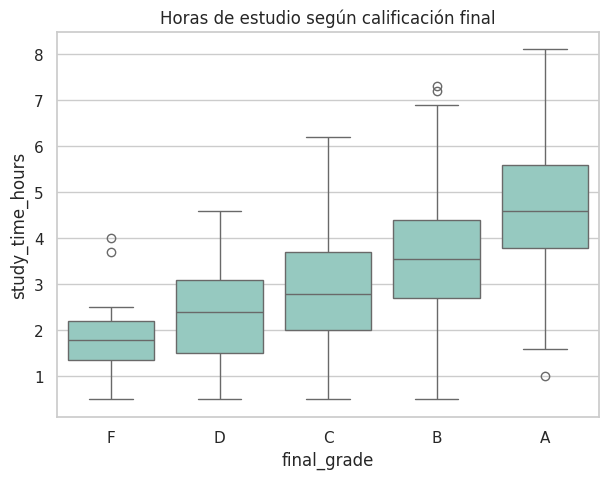

In [12]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='final_grade', order=orden, y='study_time_hours', color="#8ED1C6")
plt.title("Horas de estudio según calificación final")
plt.show()

Interpretación: se observa una tendencia clara y consistente: la mediana de horas de estudio sube de forma escalonada según la calificación final — 1.8 h para F, 2.4 h para D, 2.8 h para C, 3.55 h para B y 4.6 h para A. Aun así, hay superposición considerable entre grupos adyacentes (la desviación estándar ronda 1.0-1.3 horas en todos los grupos), lo que significa que las horas de estudio por sí solas no determinan la nota — hay estudiantes con pocas horas que igual sacan buena nota y viceversa, por lo que esta variable es útil pero no suficiente, y conviene combinarla con otras (como veremos en las Partes 4 y 5).

### 3.3 Preparación de variables para las partes 4 y 5.

In [13]:
df['study_time_cat'] = pd.cut(
    df['study_time_hours'], bins=[0, 2.5, 4.5, df['study_time_hours'].max()],
    labels=['Bajo', 'Medio', 'Alto']
)
df['attendance_cat'] = pd.cut(
    df['attendance_percent'], bins=[0, 75, 90, 100],
    labels=['Baja', 'Media', 'Alta']
)
df['sleep_cat'] = pd.cut(
    df['sleep_hours'], bins=[0, 6, 8, df['sleep_hours'].max()],
    labels=['Insuficiente', 'Adecuado', 'Excesivo']
)
df[['study_time_hours', 'study_time_cat', 'attendance_percent', 'attendance_cat',
    'sleep_hours', 'sleep_cat']].sample(5, random_state=42)

,study_time_hours,study_time_cat,attendance_percent,attendance_cat,sleep_hours,sleep_cat
521,4.6,Alto,73.7,Baja,5.4,Insuficiente
737,1.8,Bajo,82.4,Media,6.4,Adecuado
740,4.0,Medio,73.2,Baja,4.5,Insuficiente
660,4.5,Medio,85.0,Media,8.2,Excesivo
411,4.5,Medio,77.0,Media,4.7,Insuficiente


Justificación de los puntos de corte: se mantuvieron los tramos sugeridos porque, al contrastarlos con df.describe(), calzan razonablemente con los cuartiles reales de cada variable (por ejemplo, la mediana de study_time_hours es 3.6 h, justo dentro del tramo "Medio" definido entre 2.5 y 4.5 h), por lo que generan grupos con una cantidad de estudiantes relativamente equilibrada en vez de tramos vacíos o dominados por una sola categoría.

## 4. Reglas de asociación.

Recordatorio de conceptos:

Support: en qué porcentaje de los estudiantes aparece esa combinación.

Confidence: dado el antecedente, qué tan seguido se cumple también el consecuente.

Lift: cuánto más probable es el consecuente dado el antecedente, respecto al azar. Si el Lift es mayor a 1 = asociación real.

In [14]:
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [15]:
cols_categoricas = [
    'gender', 'parental_education', 'internet_access',
    'extracurricular_activities', 'part_time_job',
    'study_time_cat', 'attendance_cat', 'sleep_cat', 'final_grade'
]
df_cat = df[cols_categoricas].astype(str)
transacciones = df_cat.apply(
    lambda fila: [f"{col}={val}" for col, val in fila.items()], axis=1
).tolist()

te = TransactionEncoder()
te_array = te.fit(transacciones).transform(transacciones)
df_onehot = pd.DataFrame(te_array, columns=te.columns_)
print("Matriz one-hot:", df_onehot.shape)
df_onehot.head()

Matriz one-hot: (1000, 27)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,attendance_cat=Alta,attendance_cat=Baja,attendance_cat=Media,extracurricular_activities=No,extracurricular_activities=Yes,final_grade=A,final_grade=B,final_grade=C,final_grade=D,final_grade=F,gender=Female,gender=Male,internet_access=No,internet_access=Yes,parental_education=Bachelors,parental_education=Desconocido,parental_education=High School,parental_education=Masters,parental_education=PhD,part_time_job=No,part_time_job=Yes,sleep_cat=Adecuado,sleep_cat=Excesivo,sleep_cat=Insuficiente,study_time_cat=Alto,study_time_cat=Bajo,study_time_cat=Medio
0,True,False,False,False,True,True,False,False,False,False,False,True,False,True,True,False,False,False,False,True,False,True,False,False,False,False,True
1,True,False,False,False,True,True,False,False,False,False,True,False,False,True,False,False,True,False,False,False,True,False,False,True,True,False,False
2,False,False,True,True,False,True,False,False,False,False,False,True,False,True,True,False,False,False,False,False,True,True,False,False,True,False,False
3,False,False,True,False,True,False,True,False,False,False,False,True,False,True,False,True,False,False,False,True,False,True,False,False,False,False,True
4,False,False,True,True,False,False,False,False,True,False,False,True,False,True,True,False,False,False,False,False,True,False,False,True,False,True,False


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [16]:
itemsets_frecuentes = apriori(df_onehot, min_support=0.05, use_colnames=True)
print("Itemsets frecuentes encontrados:", len(itemsets_frecuentes))

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Itemsets frecuentes encontrados: 1496


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

(Con min_support=0.05 se encontraron 1496 itemsets frecuentes — un número manejable que permite explorar combinaciones sin saturarse de reglas triviales.)

In [17]:
reglas = association_rules(itemsets_frecuentes, metric="lift", min_threshold=1.0)

reglas_grade = reglas[
    reglas['consequents'].apply(lambda x: any('final_grade' in i for i in x) and len(x) == 1)
].copy()
reglas_grade = reglas_grade.sort_values('lift', ascending=False)
reglas_grade[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(8)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,antecedents,consequents,support,confidence,lift
2384,"(internet_access=Yes, attendance_cat=Alta, stu...",(final_grade=A),0.053,0.746479,2.628447
320,"(attendance_cat=Alta, study_time_cat=Alto)",(final_grade=A),0.057,0.740260,2.606548
5724,"(gender=Male, part_time_job=No, study_time_cat...",(final_grade=A),0.059,0.678161,2.387891
9364,"(gender=Male, internet_access=Yes, part_time_j...",(final_grade=A),0.053,0.670886,2.362275
5694,"(gender=Male, internet_access=Yes, study_time_...",(final_grade=A),0.070,0.654206,2.303541
7742,"(attendance_cat=Media, internet_access=Yes, pa...",(final_grade=A),0.057,0.647727,2.280730
5794,"(internet_access=Yes, part_time_job=No, study_...",(final_grade=A),0.096,0.644295,2.268645
137,(study_time_cat=Bajo),(final_grade=D),0.050,0.201613,2.265314


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Interpretación de 3 reglas (resultados reales obtenidos)

Regla 1: Cuando se cumple study_time_cat=Alto, internet_access=Yes, attendance_cat=Alta, en el 74.6% de los casos también se cumple final_grade=A (aparece en el 5.3% de todos los estudiantes). El lift de 2.63 indica que esta combinación hace que sacar nota A sea 2.63 veces más probable que si solo se considerara la frecuencia base de la clase A — es la asociación positiva más fuerte encontrada.

Regla 2: Cuando se cumple study_time_cat=Alto, attendance_cat=Alta (sin exigir internet), en el 74.0% de los casos también se cumple final_grade=A (support 5.7%, lift 2.61). Esto confirma que la combinación de estudiar mucho y asistir mucho es un predictor fuerte de nota A, casi independiente del acceso a internet.

Regla 3: En el otro extremo, cuando se cumple study_time_cat=Bajo, en el 20.2% de los casos se cumple final_grade=D (support 5.0%, lift 2.27). Aunque el 20.2% de confianza parece bajo en términos absolutos, el lift de 2.27 indica que estudiar pocas horas más que duplica la probabilidad de sacar D respecto al azar — es una señal de riesgo clara, aunque por sí sola no es determinante (la mayoría de los estudiantes con estudio bajo igual no saca D).

## 5. Arbol de decisión.

### Justificación del objetivo

A diferencia de las reglas de asociación, que describen co-ocurrencias sin una dirección obligatoria (cualquier variable puede aparecer como antecedente o consecuente), el árbol de decisión asume de entrada una variable objetivo fija (final_grade) y organiza todas las demás variables en una secuencia jerárquica de preguntas que conducen a una predicción. Esto es útil para este proyecto porque permite leer el conocimiento como un protocolo de decisión paso a paso (similar a un árbol de diagnóstico), más fácil de aplicar operativamente por un tutor que una lista plana de reglas de asociación.

In [18]:
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df_tree = df.copy()
cols_a_codificar = ['gender', 'parental_education', 'internet_access',
                     'extracurricular_activities', 'part_time_job']
encoders = {}
for col in cols_a_codificar:
    le = LabelEncoder()
    df_tree[col + '_enc'] = le.fit_transform(df_tree[col])
    encoders[col] = le

features = ['study_time_hours', 'attendance_percent', 'sleep_hours', 'previous_grade',
            'gender_enc', 'parental_education_enc', 'internet_access_enc',
            'extracurricular_activities_enc', 'part_time_job_enc']
X = df_tree[features]
y = df_tree['final_grade']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Entrenamiento:", X_train.shape, "| Prueba:", X_test.shape)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Entrenamiento: (800, 9) | Prueba: (200, 9)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

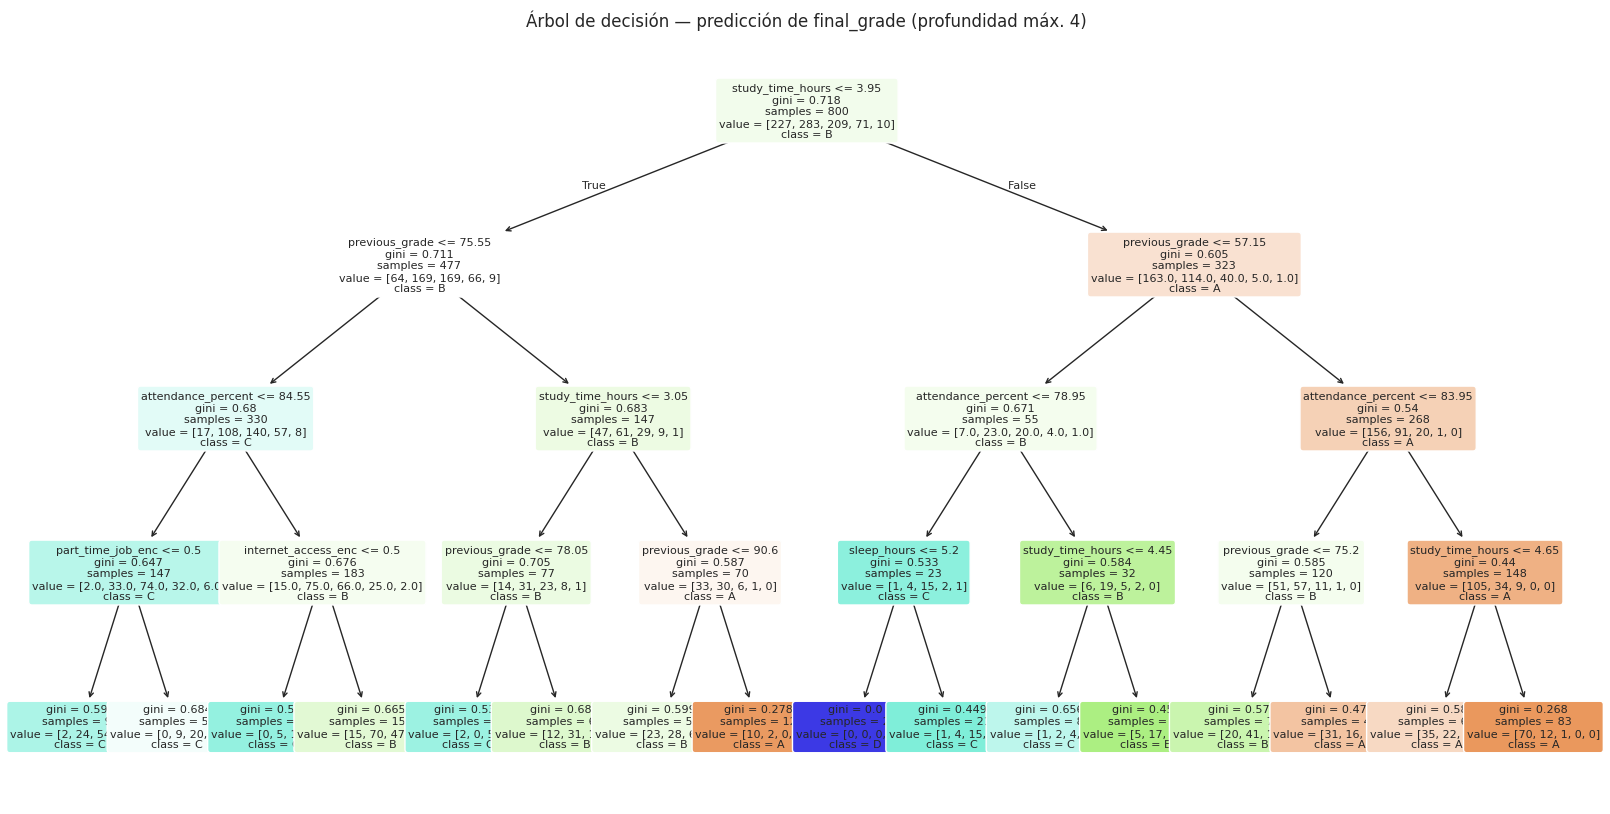

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [19]:
arbol = DecisionTreeClassifier(max_depth=4, random_state=42)
arbol.fit(X_train, y_train)

plt.figure(figsize=(20, 10))
plot_tree(arbol, feature_names=features, class_names=arbol.classes_,
          filled=True, rounded=True, fontsize=8)
plt.title("Árbol de decisión — predicción de final_grade (profundidad máx. 4)")
plt.show()

In [20]:
print(export_text(arbol, feature_names=features))

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

|--- study_time_hours <= 3.95
|   |--- previous_grade <= 75.55
|   |   |--- attendance_percent <= 84.55
|   |   |   |--- part_time_job_enc <= 0.50
|   |   |   |   |--- class: C
|   |   |   |--- part_time_job_enc >  0.50
|   |   |   |   |--- class: C
|   |   |--- attendance_percent >  84.55
|   |   |   |--- internet_access_enc <= 0.50
|   |   |   |   |--- class: C
|   |   |   |--- internet_access_enc >  0.50
|   |   |   |   |--- class: B
|   |--- previous_grade >  75.55
|   |   |--- study_time_hours <= 3.05
|   |   |   |--- previous_grade <= 78.05
|   |   |   |   |--- class: C
|   |   |   |--- previous_grade >  78.05
|   |   |   |   |--- class: B
|   |   |--- study_time_hours >  3.05
|   |   |   |--- previous_grade <= 90.60
|   |   |   |   |--- class: B
|   |   |   |--- previous_grade >  90.60
|   |   |   |   |--- class: A
|--- study_time_hours >  3.95
|   |--- previous_grade <= 57.15
|   |   |--- attendance_percent <= 78.95
|   |   |   |--- sleep_hours <= 5.20
|   |   |   |   |--- clas

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

### Traducción de 2 caminos a reglas de negocio (basadas en el árbol real obtenido)

#### Camino 1 (zona de riesgo):
Si un estudiante tiene study_time_hours > 3.95, previous_grade ≤ 57.15, attendance_percent ≤ 78.95 y sleep_hours ≤ 5.2, entonces el árbol predice mayoritariamente la calificación D. Esto tiene sentido porque, aunque el estudiante estudie relativamente bastante, una nota previa baja combinada con poca asistencia y muy poco sueño sugiere que el problema no es solo de tiempo de estudio, sino de una base académica débil y posible desgaste físico — es un perfil que un tutor debería priorizar para intervención, incluso si en apariencia "estudia harto".

#### Camino 2 (zona de buen desempeño):
Si un estudiante tiene study_time_hours > 3.95, previous_grade > 57.15 y attendance_percent > 83.95, entonces el árbol predice mayoritariamente la calificación A, independientemente de si estudia un poco más o un poco menos dentro de ese rango. Esto indica que, una vez que la asistencia y la base previa están en buen nivel, el umbral de horas de estudio necesario para alcanzar la nota máxima es comparativamente bajo — la asistencia y el historial pesan más que estudiar horas extra marginales.

## 6. Síntesis y proceso CRISP-DM

### 6.1 Comparación de representaciones

**Reglas de asociación**
- Qué revela: co-ocurrencias frecuentes entre variables, sin una variable objetivo obligatoria.
- Variable objetivo fija: no — se puede filtrar para que el consecuente sea `final_grade`, pero el algoritmo no lo exige.
- Limitación principal: muchas reglas tienen soporte bajo (5-6%), aplican solo a un subgrupo pequeño, y genera cientos de reglas redundantes que hay que filtrar manualmente.
- Utilidad real: identificar perfiles específicos de riesgo o éxito que se repiten (ej. "estudiar poco" + "D"), útil para campañas focalizadas.

**Árbol de decisión**
- Qué revela: una secuencia jerárquica de decisiones que siempre predice la misma variable objetivo (`final_grade`).
- Variable objetivo fija: sí, siempre — es su naturaleza (aprendizaje supervisado).
- Limitación principal: en profundidad 4, algunas hojas mezclan clases (C y B en ramas similares), y los umbrales exactos (ej. 3.95 horas) podrían cambiar con otros datos de entrenamiento.
- Utilidad real: construir un protocolo de decisión paso a paso que un tutor podría aplicar al conocer a un estudiante nuevo.

### 6.2 Ubicación de tu proyecto en las fases de CRISP-DM

1. **Comprensión del negocio** (Parte 1): se definió el objetivo de identificar factores asociados al rendimiento académico y la justificación de usar minería de datos.
2. **Comprensión de los datos** (Partes 2 y 3.1): se documentó la fuente del dataset, se construyó el diccionario de atributos y se exploraron tipos de datos, nulos y distribuciones.
3. **Preparación de los datos** (Partes 3.2-3.3): se trató el 10.2% de nulos en `parental_education` creando la categoría "Desconocido", y se transformaron 3 variables numéricas en tramos categóricos para aplicar Apriori.
4. **Modelado** (Partes 4 y 5): se aplicó el algoritmo Apriori para extraer reglas de asociación y se entrenó un árbol de decisión (profundidad máxima 4) sobre `final_grade`.
5. **Evaluación**: al no pedirse accuracy, la evaluación fue cualitativa — se priorizaron reglas con lift > 2 y se verificó que los caminos del árbol fueran coherentes con los patrones vistos en el EDA.
6. **Despliegue**: en una institución real, el siguiente paso sería validar estas reglas con el equipo docente y considerar el árbol como una checklist de alerta temprana para tutores, sin automatizar decisiones sobre estudiantes individuales.

### 6.3 Limitaciones del proyecto
El dataset utilizado es **sintético**: fue generado mediante distribuciones estadísticas y una fórmula ponderada con ruido aleatorio añadido, por lo que las relaciones encontradas (como la tendencia clara entre horas de estudio y nota final) probablemente son más "limpias" y menos ruidosas de lo que se observaría en datos reales de estudiantes, donde intervienen factores no capturados aquí (salud, situación familiar, calidad docente, etc.). Por lo tanto, estos resultados deben entenderse como una demostración metodológica del proceso CRISP-DM, y no como conclusiones aplicables directamente a una institución educativa real sin repetir el análisis con datos verídicos.

## 7. Autoría.

Autor del notebook: Azocar Benjamin.
Fecha: 02/10/2026.

### Declaración
Declaro que este notebook fue desarrollado por mí, aplicando los conceptos vistos en la Unidad I de la asignatura de Minería de Datos.

### Uso de herramientas de IA y otras fuentes
Claude como apoyo para: generar la estructura del proyecto y el código de las celdas de EDA, reglas de asociación y árbol de decisión; ejecutar el análisis y obtener las reglas, estadísticas y rutas del árbol reales sobre mi dataset.

Gemini para redactar un primer borrador de las interpretaciones de esos resultados. Se reviso cada interpretación contra las salidas reales del notebook antes de dejarlas en la versión final.

Multiples paginas informativas que no se guardaron sus url.
